In [14]:
# external imports
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from pathlib import Path
from typing import List
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
        """Load and combine multiple experiment CSVs. Do simple data processing for later convenience"""
        dfs = []
        for path in csv_paths:
            df = pd.read_csv(path, index_col=0)
            df['source_file'] = Path(path).parent.name  # track which experiment it came from
            dfs.append(df)
        
        combined = pd.concat(dfs, ignore_index=True)
        
        # add in diff representations of red params for convenience
        combined[['resizeTrigger', 'sizeLimit']] = combined['reduce_triggerSz_sizeLim'].str.strip('()').str.split(',', expand=True).astype(int)
        combined['gap_size_range_tuple'] = combined['gap_size_range'].apply(ast.literal_eval)
        combined['reduce_triggerSz_sizeLim_tuple'] = combined['reduce_triggerSz_sizeLim'].apply(ast.literal_eval)
        
        combined['time_norm'] = combined['sumtest_time_mean'] / combined['sumtest_time_mean'].max()
        combined['coverage_norm'] = combined['result_coverage_mean'] / combined['result_coverage_mean'].max()
        combined['efficiency'] = combined['coverage_norm'] / combined['time_norm']
        return combined

In [33]:
paths = ['data/results/1102099361/gap_sweeping400/gs100000_red500_250_sweep/results_sd1102099361.csv', 'data/results/1102099361/gap_sweeping400/gs100000_red500_100_sweep/results_sd1102099361.csv', 'data/results/1102099361/gap_sweeping400/gs100000_red500_10_sweep/results_sd1102099361.csv', 'data/results/1102099361/gap_sweeping400/gs100000_red150_100_sweep/results_sd1102099361.csv', 'data/results/1102099361/gap_sweeping400/gs100000_red150_10_sweep/results_sd1102099361.csv', 'data/results/1102099361/gap_sweeping400/gs100000_red70_50_sweep/results_sd1102099361.csv', 'data/results/1102099361/gap_sweeping400/gs100000_red15_10_sweep/results_sd1102099361.csv', 'data/results/1102099361/gap_sweeping400/gs100000_red3_1_sweep/results_sd1102099361.csv']
df = load_all_csvs(paths)
df


,master_seed,data_type,num_trials,dataset_size,uncertain_ratio,interval_size_range,mult_size_range,num_intervals,start_interval_range,gap_size,interval_width,num_intervals_range,gap_size_range,interval_width_range,reduce_triggerSz_sizeLim,independent_variable,distribution,min_time_mean,min_time_std,max_time_mean,max_time_std,sum_time_mean,sum_time_std,sumtest_time_mean,sumtest_time_std,sum_results,reduce_calls_mean,max_interval_count_mean,total_interval_count_mean,combine_calls_mean,result_size_mean,minEffectiveIntervalCountMean,convergedToTotSize,result_coverage_mean,source_file,resizeTrigger,sizeLimit,gap_size_range_tuple,reduce_triggerSz_sizeLim_tuple,time_norm,coverage_norm,efficiency
0,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(1000, 3000)","(1, 2)","(500, 250)",gap_size_range,DistributionType.UNIFORM,15.641667,1.850934,0.895333,0.059957,16.664667,0.039466,16.331000,0.185003,"[NumericRange(195781, 196182, '[)'), NumericRa...",122.0,2375.0,232625.0,400.0,3.0,3.0,3234815.0,3234815.0,gs100000_red500_250_sweep,500,250,"(1000, 3000)","(500, 250)",0.413248,0.010092,0.024421
1,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(2000, 6000)","(1, 2)","(500, 250)",gap_size_range,DistributionType.UNIFORM,16.362000,1.126340,1.462333,0.863148,17.224333,0.146957,17.020667,0.114619,"[NumericRange(200606, 201007, '[)'), NumericRa...",136.0,2475.0,239115.0,400.0,3.0,3.0,6357837.0,6357837.0,gs100000_red500_250_sweep,500,250,"(2000, 6000)","(500, 250)",0.430699,0.019835,0.046053
2,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(5000, 15000)","(1, 2)","(500, 250)",gap_size_range,DistributionType.UNIFORM,16.531333,0.287751,0.874667,0.012472,20.279667,1.536122,20.339667,2.029957,"[NumericRange(198228, 198629, '[)'), NumericRa...",168.0,2475.0,257405.0,400.0,3.0,3.0,15948035.0,15948035.0,gs100000_red500_250_sweep,500,250,"(5000, 15000)","(500, 250)",0.514685,0.049754,0.096669
3,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(10000, 30000)","(1, 2)","(500, 250)",gap_size_range,DistributionType.UNIFORM,15.564667,0.158075,0.865000,0.021354,22.860000,0.382876,21.555667,0.164553,"[NumericRange(203997, 204398, '[)'), NumericRa...",202.0,2450.0,280565.0,400.0,3.0,3.0,31946861.0,31946861.0,gs100000_red500_250_sweep,500,250,"(10000, 30000)","(500, 250)",0.545455,0.099667,0.182722
4,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(100000, 300000)","(1, 2)","(500, 250)",gap_size_range,DistributionType.UNIFORM,18.036667,1.950907,0.856333,0.011264,41.964333,7.475560,39.518667,5.081728,"[NumericRange(193552, 193953, '[)'), NumericRa...",397.0,1250.0,440705.0,400.0,174.0,174.0,320244405.0,320244405.0,gs100000_red500_250_sweep,500,250,"(100000, 300000)","(500, 250)",1.000000,0.999088,0.999088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(1000, 3000)","(1, 2)","(3, 1)",gap_size_range,DistributionType.UNIFORM,15.273333,0.152014,0.857000,0.008602,0.519667,0.104926,0.478667,0.064505,"[NumericRange(195781, 3431805, '[)')]",399.0,25.0,2020.0,400.0,1.0,1.0,3236024.0,3236024.0,gs100000_red3_1_sweep,3,1,"(1000, 3000)","(3, 1)",0.012112,0.010096,0.833495
36,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(2000, 6000)","(1, 2)","(3, 1)",gap_size_range,DistributionType.UNIFORM,16.265000,0.266785,0.858333,0.023613,0.439667,0.010209,0.418000,0.005657,"[NumericRange(200606, 6561660, '[)')]",399.0,25.0,2020.0,400.0,1.0,1.0,6361054.0,6361054.0,gs100000_red3_1_sweep,3,1,"(2000, 6000)","(3, 1)",0.010577,0.019845,1.876192
37,1102099361,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(5000, 15000)","(1, 2)","(3, 1)",gap_size_range,DistributionType.UNIFORM,18.086333,0.549065,0.888333,0.058818,0.44666

In [35]:
class temp:
    resultFilepath = "yoyo"
    iv = 'gap_size_range'
    param_str = ""
    REDUCE_PARAM_NAME = 'reduce_triggerSz_sizeLim'

    
    def plot_efficiency_vs_iv(self, df: pd.DataFrame, filename="efficiency_vs_iv.pdf"):
        iv = self.iv 
        filename = f"{self.resultFilepath}/{filename}"
        
        with PdfPages(filename) as pdf:
            # heatmap: reduce_triggers(x) vs IV(y)
            pivot_eff = df.pivot_table(
                index=iv,
                columns='reduce_triggerSz_sizeLim',
                values='efficiency',
                aggfunc='mean'
            )
            plt.figure(figsize=(6,3))
            sns.heatmap(pivot_eff, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 6})
            plt.title("Efficiency (coverage_norm/time_norm)")
            plt.xlabel("reduce_triggerSz_sizeLim")
            plt.ylabel(iv)
            pdf.savefig(bbox_inches='tight')
            plt.close()
            
            iv_values = sorted(df[iv].unique())
            red_configs = sorted(df['reduce_triggerSz_sizeLim'].unique())
            fig, axes = plt.subplots(1, len(iv_values), figsize=(4*len(iv_values), 3))
            axes = axes.flatten() if len(iv_values) > 1 else [axes]
            fig.text(0.5, 0.05, self.param_str, ha='center', va='center', fontsize=7, color='black', wrap=True)
    
            handles, labels = None, None
            for i, val in enumerate(iv_values):
                ax = axes[i]
                sub_df = df[df[iv] == val]
                for r in red_configs:
                    r_df = sub_df[sub_df['reduce_triggerSz_sizeLim'] == r]
                    ax.scatter(r_df['time_norm'], r_df['coverage_norm'], label=str(r), s=50)
    
                if handles is None:
                    handles, labels = ax.get_legend_handles_labels()
    
                ax.set_title(f'{iv}={val}')
                ax.set_xlabel('relative time')
                ax.set_ylabel('relative coverage')
                ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
                ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
                ax.grid(True, alpha=0.3)
    
            plt.tight_layout(rect=[0, 0.08, 0.85, 1])
            pdf.savefig(bbox_inches='tight')
            plt.close()
    
            fig = plt.figure(figsize=(6,2))
            fig.legend(handles, labels, title='(trigger, size_limit)', loc='center', fontsize=8)
            pdf.savefig(bbox_inches='tight')
            plt.close()

    def plot_time_coverage_by_reduce(self, df: pd.DataFrame) -> str:
        ''' plot time and coverage vs gap '''

        indep_variable = self.iv

        # Sort dataframe by dataset size
        df_sorted = df.sort_values(indep_variable)

        # Group by reduction parameters
        dfg = df_sorted.groupby(self.REDUCE_PARAM_NAME)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)       
        fig.text(0.5, -0.02, self.param_str, ha='center', fontsize=7, color='black')
        for p, group in dfg:
            # Make sure each group is sorted by IV
            group = group.sort_values('gap_size_range_tuple')
            x = group[indep_variable]
            y_time = group['sum_time_mean']
            y_time_err = group['sum_time_std']
            y_coverage = group['result_coverage_mean']

            # Plot time and coverage
            ax1.errorbar(x, y_time, yerr=y_time_err, fmt='o-', capsize=5, label=str(p))
            ax2.errorbar(x, y_coverage, fmt='o-', capsize=5, label=str(p))

        # TIME axis labels
        ax1.set_ylabel('Time (ms)')
        ax1.set_title(f'Time vs {indep_variable} by Reduction Parameters')
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
        ax1.legend(title='(trigger, size_limit)',loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

        # COVERAGE axis labels
        ax2.set_ylabel('Coverage')
        ax2.set_xlabel(indep_variable)
        ax2.set_title(f'Coverage vs {indep_variable} by Reduction Parameters')
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
        ax2.legend(title='(trigger, size_limit)',loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

        plt.tight_layout()
        # outfile = f'gap_vs_time_coverage_{self.master_seed}'
        # outpath = f"{self.resultFilepath}/{outfile}"
        # plt.savefig(outpath, dpi=300, bbox_inches='tight')
        plt.show()
        # plt.close()
        # return outpath


    def plot_time_vs_coverage_all_iv(self, df: pd.DataFrame, filename="time_vs_coverage_all_iv.pdf"):
        """
        Plots Time vs Coverage, grouping by the independent variable (iv) and reduce_triggerSz_sizeLim.
        Automatically handles special cases like gap_size_range tuples for proper x-axis ordering.
        """
    
        iv = self.iv
        # Special cases where the x-axis should use the tuple form for proper ordering
        if iv in ["gap_size", "gap_size_range"]:
            iv = "gap_size_range_tuple"
    
        # Aggregate data by IV and reduce_triggerSz_sizeLim
        if iv in df.columns:
            agg_df = df.groupby([iv, 'reduce_triggerSz_sizeLim']).agg({
                'time_norm': 'mean',
                'coverage_norm': 'mean'
            }).reset_index()
        else:
            raise ValueError(f"Column '{iv}' not found in dataframe")
    
        # Skip plotting if dataframe is empty
        if agg_df.empty:
            print(f"No data available for plotting Time vs Coverage using IV '{iv}'")
            return
    
        filename = f"{self.resultFilepath}/{filename}"
        with PdfPages(filename) as pdf:
    
            # Helper to create the scatter plot
            def scatter_plot(ax, hue, style=None, title_suffix=""):
                sns.scatterplot(
                    data=agg_df,
                    x='time_norm',
                    y='coverage_norm',
                    hue=hue,
                    style=style,
                    s=60,
                    ax=ax
                )
                ax.set_xlabel("Relative Time")
                ax.set_ylabel("Relative Coverage")
                ax.set_title(f"Time vs Coverage {title_suffix}")
                ax.grid(alpha=0.3)
                ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
                ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
                ax.legend(title=f'{iv} / red', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
    
            # Plot 1: hue = reduce_triggerSz_sizeLim, style = IV
            fig, ax = plt.subplots(figsize=(8, 5))
            scatter_plot(ax, hue='reduce_triggerSz_sizeLim', style=iv, title_suffix="(style by IV)")
            fig.text(0.5, 0.05, self.param_str, ha='center', va='center', fontsize=7, color='black', wrap=True)
            plt.tight_layout()
            pdf.savefig(bbox_inches='tight')
            plt.close()
    
            # Plot 2: hue = reduce_triggerSz_sizeLim, no style
            fig, ax = plt.subplots(figsize=(8, 5))
            scatter_plot(ax, hue='reduce_triggerSz_sizeLim', title_suffix="(no style)")
            fig.text(0.5, 0.05, self.param_str, ha='center', va='center', fontsize=7, color='black', wrap=True)
            plt.tight_layout()
            pdf.savefig(bbox_inches='tight')
            plt.close()

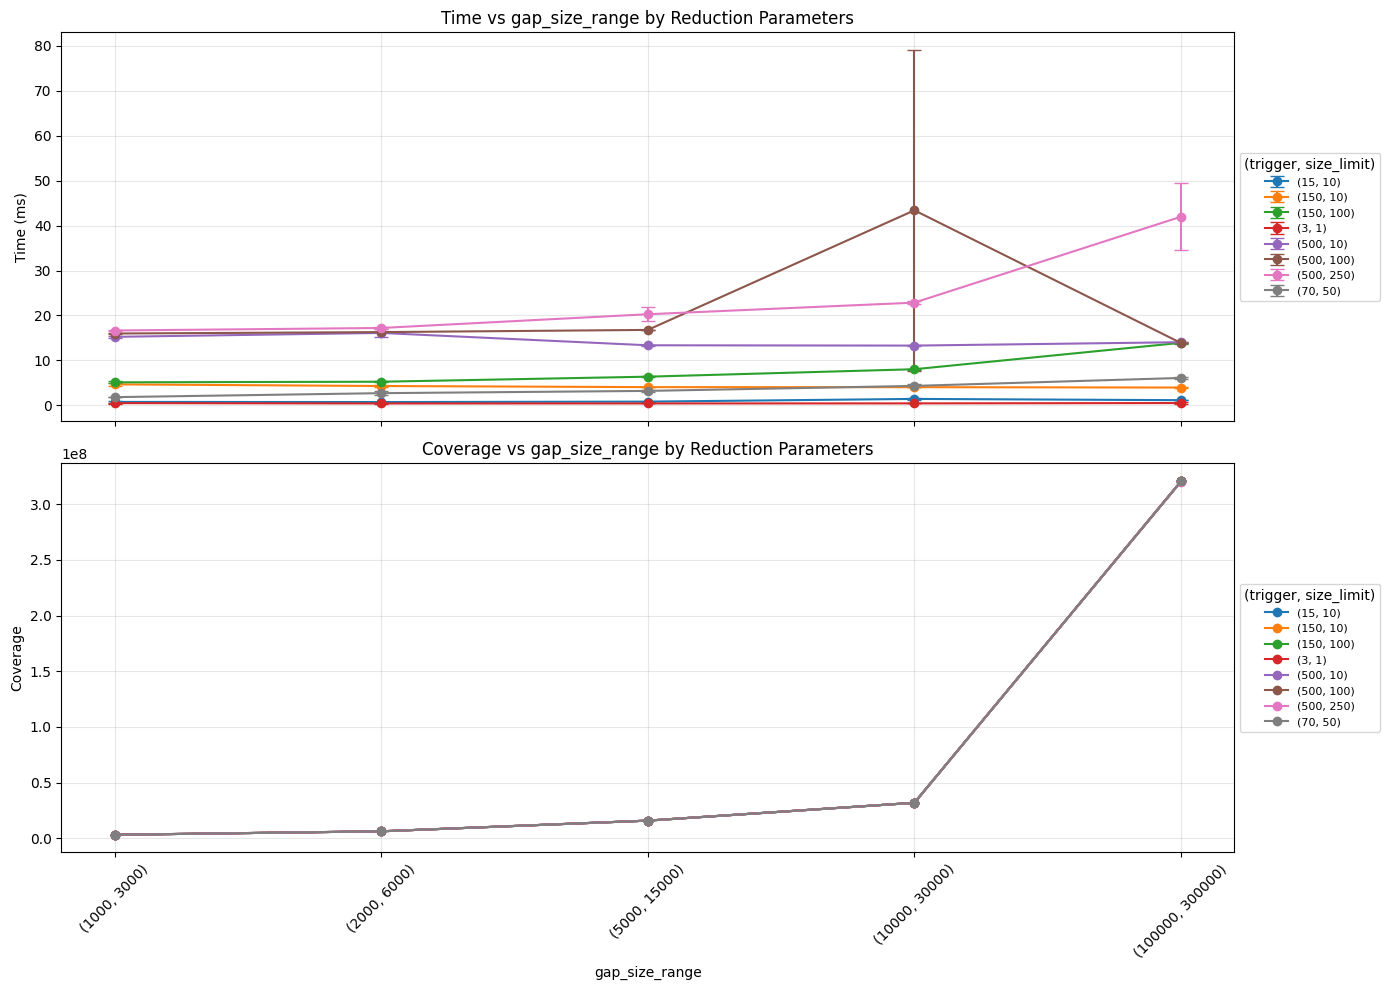

In [36]:
a = temp()
# a.plot_efficiency_vs_iv(df
a.plot_time_coverage_by_reduce(df)
a.plot_time_vs_coverage_all_iv(df)